# Load dataset

In [1]:
import kagglehub
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download(
    "jehanbhathena/weather-dataset",
    output_dir='data'
)

print("Path to dataset files:", path)

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "dataset"

print("DATA_FILE directory:", DATA_FILE)

Path to dataset files: data
DATA_FILE directory: data\dataset


# 1.Data inspection

## 1.1 Number and type of classes

In [2]:
classes = sorted([file.name for file in DATA_FILE.iterdir() if file.is_dir()])

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 11
Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


## 1.2 Few image examples

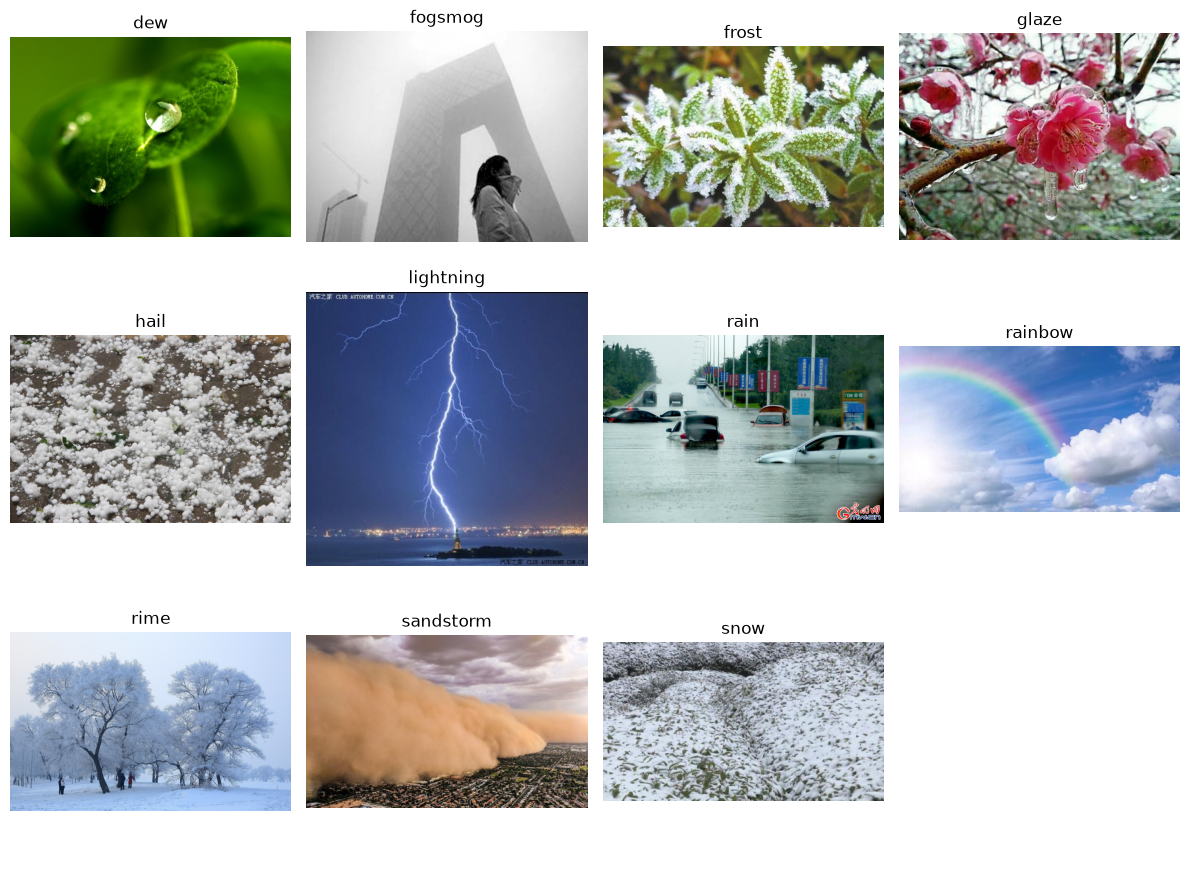

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

# Change the list[row, columns] => list[index]
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_path = DATA_FILE / class_name
    # Take first found file
    image_path = next(class_path.glob("*.jpg"))

    image = Image.open(image_path)

    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis("off")

# We got 11 classes so the last plot is hidden
axes[-1].axis("off")

plt.tight_layout()
plt.show()

## 1.3 Class distribution

In [4]:
import pandas as pd

class_counts = []

for class_name in classes:
    class_path = DATA_FILE / class_name
    images = list(class_path.glob("*.jpg"))

    class_counts.append({
        "class": class_name,
        "count": len(images)
    })

df_counts = pd.DataFrame(class_counts)

df_counts

,class,count
0,dew,698
1,fogsmog,851
2,frost,475
3,glaze,639
4,hail,591
5,lightning,377
6,rain,526
7,rainbow,232
8,rime,1160
9,sandstorm,692


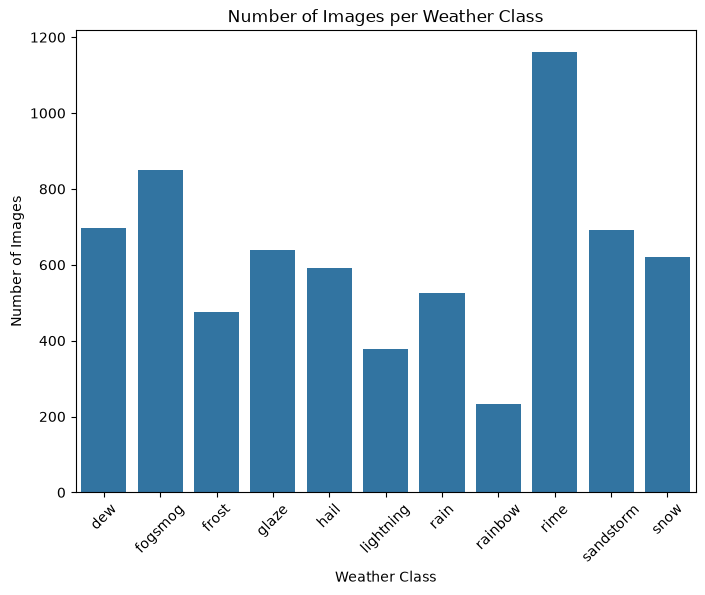

In [5]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.barplot(
    df_counts,
    x="class",
    y="count"
)

plt.title("Number of Images per Weather Class")
plt.xlabel("Weather Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

### Observation
We can see that the class distribution is not perfectly balanced. Two classes have fewer than 400 images, while one class contains almost 1,200 images. This imbalance may affect the model's performance, as the CNN could learn to recognize classes with more training examples more easily than underrepresented classes. Therefore, we should consider this imbalance when evaluating the model, especially when analyzing the confusion matrix and F1-score.

## 1.4 Image sizes

In [6]:
from collections import Counter

image_sizes = []

for class_name in classes:
    class_path = DATA_FILE / class_name

    for image_path in class_path.glob("*.jpg"):
        with Image.open(image_path) as image:
            image_sizes.append(image.size)

size_counts = Counter(image_sizes)

print("Number of unique image sizes:", len(size_counts))

for size, count in size_counts.most_common(20):
    print(f"{size}: {count} images")

Number of unique image sizes: 2344
(400, 266): 792 images
(400, 300): 449 images
(400, 265): 144 images
(300, 400): 125 images
(426, 240): 119 images
(400, 264): 86 images
(275, 183): 85 images
(400, 299): 80 images
(400, 267): 72 images
(400, 400): 71 images
(400, 240): 66 images
(400, 250): 64 images
(400, 268): 62 images
(400, 280): 57 images
(1200, 800): 52 images
(1024, 768): 48 images
(427, 240): 44 images
(259, 194): 43 images
(266, 400): 42 images
(400, 258): 30 images


In [7]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Minimum width: 117
Maximum width: 4863
Minimum height: 91
Maximum height: 3174


### Observation
The images have highly varying dimensions, with 2,344 unique image sizes across the dataset. The most common resolution is 400×266, but many other dimensions are present. Since CNN models require images of a consistent size within each batch, all images will be resized to a fixed resolution during preprocessing.

# 2. Data Preprocessing
- Train / Validation / Test Split – split the dataset into three subsets to train the model, validate its performance, and evaluate it on unseen data
- Resize the Images – resize all images to the same dimensions because the original images have different sizes
- Data Augmentation (Train Dataset) – apply random transformations to training images to increase data variety and reduce the risk of overfitting
- Change Data into Tensors – convert images into tensors so they can be processed by PyTorch
- Data Normalization – scale pixel values to make the training process more stable and efficient

## 2.1 Train / Validation / Test Split

In [13]:
# Create path and labels of the images
image_paths = []
labels = []

for class_name in classes:
    class_path = DATA_FILE / class_name

    for image_path in class_path.glob("*.jpg"):
        image_paths.append(image_path)
        labels.append(class_name)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 6862
Total labels: 6862


In [16]:
from sklearn.model_selection import train_test_split

# Train (70%), Validation + Test (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

# Validation (15%), Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

Training images: 4803
Validation images: 1029
Test images: 1030


## 2.2 Image Preprocessing
The training images are augmented to increase data diversity and reduce the risk of overfitting. All images are resized to a fixed resolution and converted into PyTorch tensors to ensure they can be processed by the CNN model.

In [23]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
    ),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# 2.3 Create WeatherDataset

In [26]:
from torch.utils.data import Dataset
from PIL import Image

class WeatherDataset(Dataset):
    def __init__(self, image_paths, labels, classes, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.classes = classes
        self.transform = transform

        self.class_to_idx = {
            class_name: idx for idx, class_name in enumerate(classes)
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")

        label = self.class_to_idx[self.labels[idx]]

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = WeatherDataset(
    X_train,
    y_train,
    classes,
    transform=train_transform
)

val_dataset = WeatherDataset(
    X_val,
    y_val,
    classes,
    transform=val_test_transform
)

test_dataset = WeatherDataset(
    X_test,
    y_test,
    classes,
    transform=val_test_transform
)

## 2.4 Visualize example of augmented image

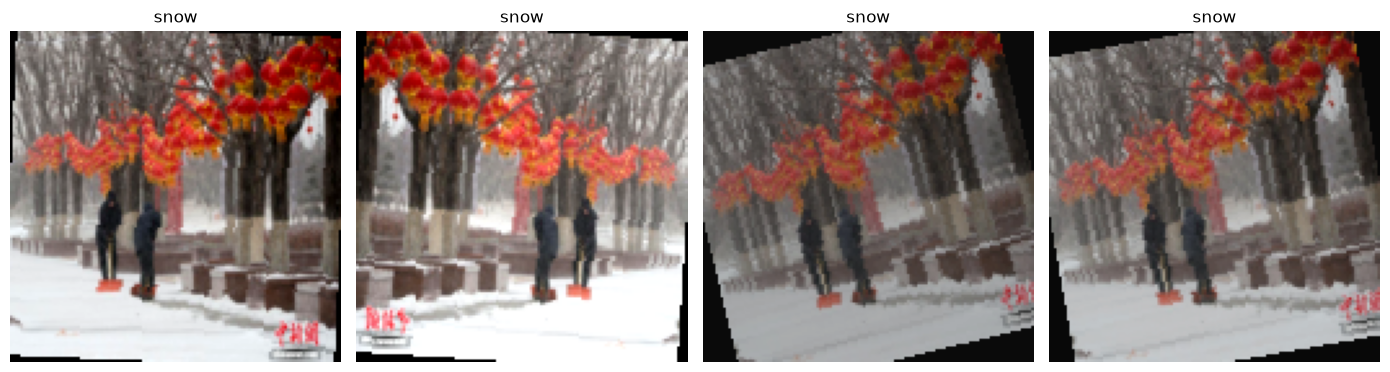

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i in range(4):
    image, label = train_dataset[0]

    # Our image has now 3 dimension [Channels, Heigth, Width] but we need [Height, Width, Channels],
    # Permute change the order of the dimensions
    image = image.permute(1, 2, 0)

    axes[i].imshow(image)
    axes[i].set_title(f"{classes[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()